# **Arabic Emotion Classification Project**

---


**Course:** AI352 - Natural Language Processing  
**Dataset:** Emotional - Tone Dataset

### **Import Libraries**

In [ ]:
!pip install camel_tools

In [ ]:
!camel_data -i disambig-mle-calima-msa-r13

No new packages will be installed.


In [ ]:
!pip install pyarabic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 5.2 MB/s eta 0:00:00


In [ ]:
import re
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import unicodedata as ud
from camel_tools.utils.normalize import( normalize_unicode, normalize_alef_ar,
                                        normalize_alef_maksura_ar, normalize_teh_marbuta_ar)
from camel_tools.utils.dediac import dediac_ar
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
import pyarabic.araby as araby
from sklearn.linear_model import LogisticRegression
from camel_tools.disambig.mle import MLEDisambiguator
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns

### **Load Dataset**

In [ ]:
import pandas as pd
url = "https://raw.githubusercontent.com/amrmalkhatib/Emotional-Tone/master/Emotional-Tone-Dataset.csv"

df = pd.read_csv(url)

### **Data Exploration**

In this section we explore the structure of the dataset and check the distribution of emotion labels

**1. Look at the basic structure**

In [ ]:
df.head()

,ID,TWEET,LABEL
0,1,الاوليمبياد الجايه هكون لسه ف الكليه ..,none
1,2,عجز الموازنه وصل ل93.7 % من الناتج المحلي يعني...,anger
2,3,كتنا نيله ف حظنا الهباب xD,sadness
3,4,جميعنا نريد تحقيق اهدافنا لكن تونس تالقت في حر...,joy
4,5,الاوليمبياد نظامها مختلف .. ومواعيد المونديال ...,none


In [ ]:
df.shape

(10065, 3)

In [ ]:
df.columns

Index(['ID', ' TWEET', ' LABEL'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10065 entries, 0 to 10064
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      10065 non-null  int64 
 1    TWEET  10064 non-null  object
 2    LABEL  10065 non-null  object
dtypes: int64(1), object(2)
memory usage: 236.0+ KB


**2. Check missing values**

In [ ]:
df.isnull().sum()

,0
ID,0
TWEET,1
LABEL,0


Drop the missing row in data cleaning section

**3. View random samples**

In [ ]:
pd.set_option('display.max_colwidth', None)
df.sample(5)

,ID,TWEET,LABEL
3655,3656,بعد اي زياده في اسعار البنزين ببقي خايفه اركب مواصلات لتكون غليت 🐣,fear
1046,1047,555 بافاري متعصب ! و عاشق ل مارتينيز ✋ حسابي عن البايرن وقليلا من مارتينيز,love
6984,6985,القصه مسليه فشخ,joy
7372,7373,الحاجه الوحيده اللي بحبها ف الاوليمبياد Rio2016 مباشر دلوقتي 😎 عروض السباحه الجماعيه 😍😍😍,none
6517,6518,لا تجعلوا اقصي امانيكم او تطمحوا له بلا امان.فالحب بلا امان كالطفل الحرام يلقي علي قارعه الطريق لامستقبل له ولا هويه ..!!,love


**4. Check class distribution**

In [ ]:
df[" LABEL"].value_counts()

,count
LABEL,
none,1550
anger,1444
joy,1281
sadness,1256
love,1220
fear,1207
sympathy,1062
surprise,1045


The distribution of classes is relatively balanced

**5. Measure text length**

In [ ]:
df[" TWEET"].astype(str).apply(lambda x: len(x.split())).describe()

,TWEET
count,10065.000000
mean,14.513164
std,6.700901
min,1.000000
25%,9.000000
50%,14.000000
75%,20.000000
max,35.000000


The average of the tweets around 14 words and most tweets falling between 9 and 20 words

**6. Check duplicates**

In [ ]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate tweets:", df[" TWEET"].duplicated().sum())

Duplicate rows: 0
Duplicate tweets: 44


In [ ]:
df[df.duplicated(" TWEET", keep=False)].sort_values(" TWEET")

,ID,TWEET,LABEL
9723,9724,2016: شخصيه الاسبوع الملك عبدالله بن عبدالعزيز غداً ختامها مسك مع شعب الملك عبدالله ومحبينه نرحب بجميع مشاركاتكم,joy
5538,5539,2016: شخصيه الاسبوع الملك عبدالله بن عبدالعزيز غداً ختامها مسك مع شعب الملك عبدالله ومحبينه نرحب بجميع مشاركاتكم,love
4738,4739,22 حمدين صباحي حيموت علي الرياسه ياعيني كل شويه يقول انتخابات مبكره لما زهقنامش عجبك عمك السيسي,joy
8634,8635,22 حمدين صباحي حيموت علي الرياسه ياعيني كل شويه يقول انتخابات مبكره لما زهقنامش عجبك عمك السيسي,anger
2309,2310,558: . ربي امسح علي قلب امي براحـه تسّر نفسها و تهديء قلبها فَـ انت ارحم الراحمين ..,love
...,...,...,...
7740,7741,ياخي كسم العرص اللي رفع علم غير علم مصر في دخله الاوليمبياد علي كسم اللي يدافع عنه علي كسم اللي مايكسموش. هي ناقصه حرقه دم؟ رجعوا حماده,anger
1091,1092,ياريت اي حد محبط من نتايج بعثه الاوليمبياد يخليه لنفسه عشان احنا مش ناقصين احباط و بنتعالج و ماشيين مشلحين الجلابيه و ماسكين كيس القسطره,none
8811,8812,ياريت اي حد محبط من نتايج بعثه الاوليمبياد يخليه لنفسه عشان احنا مش ناقصين احباط و بنتعالج و ماشيين مشلحين الجلابيه و ماسكين كيس القسطره,sadness
7214,7215,يلاحظ في مقدمه الرساله ونهايتها اطراء جم لعلماء حائل ولاسره ال الرشيد يدل علي اهميه حائل العلميه انذاك.,joy


In [ ]:
multi_labels = df.groupby(" TWEET")[" LABEL"].nunique()
print("Tweets with more than one label:", (multi_labels > 1).sum())

Tweets with more than one label: 8


only 8 duplicated tweets have different labels while the rest of the duplicated tweets share the same label

**7. Most Common Words**

In [ ]:
all_words = " ".join(df[" TWEET"].astype(str)).split()
word_counts = Counter(all_words)

print(word_counts.most_common(20))

[('في', 3601), ('من', 2625), ('الاوليمبياد', 2545), ('و', 1651), (':', 1368), ('علي', 1364), ('ان', 1041), ('الله', 1035), ('..', 963), ('اللي', 947), ('انا', 917), ('يا', 906), ('لا', 738), ('كل', 721), ('ما', 702), ('مش', 690), ('خايفه', 642), ('،', 608), ('مصر', 599), ('.', 575)]


the most frequent words are stopwords and punctuation

**8. Check Quality**

In [ ]:
has_url = df[" TWEET"].astype(str).str.contains(r"http\S+|www\S+", regex=True).sum()
has_mention = df[" TWEET"].astype(str).str.contains(r"@\w+", regex=True).sum()
has_hashtag = df[" TWEET"].astype(str).str.contains(r"#\S+", regex=True).sum()

print("tweets with URLs:", has_url)
print("tweets with mentions:", has_mention)
print("tweets with hashtags:", has_hashtag)

tweets with URLs: 0
tweets with mentions: 0
tweets with hashtags: 0


**9. Visualize**

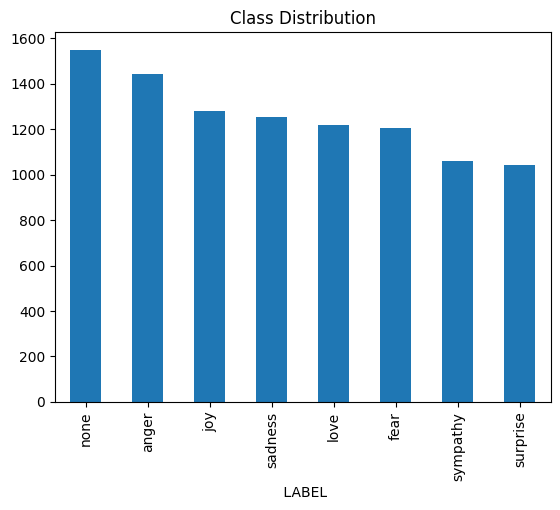

In [ ]:
df[" LABEL"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.show()

**what we found**

*   The dataset is balanced with moderate length of the tweets
*   There are no urls or mentions or hashtags but the stopwords and punctuation present
*   8 duplicate tweets have multiple labels






### **Data Cleaning**
We clean and prepare the text data before applying the models

In [ ]:
clean_df = df.copy()

In [ ]:
# drop thee missing row
clean_df = clean_df.dropna(subset = [' TWEET'])

In [ ]:
clean_df.isnull().sum()

,0
ID,0
TWEET,0
LABEL,0


In [ ]:
# normalization
def normalize_tweet(text):
    text = str(text)

    text = normalize_unicode(text)
    text = normalize_alef_ar(text)
    text = normalize_alef_maksura_ar(text)
    text = normalize_teh_marbuta_ar(text)
    text = " ".join(text.split())
    return text

clean_df["normalized_tweet"] = clean_df[" TWEET"].apply(normalize_tweet)

In [ ]:
# Handling Diacritics
clean_df["no_diacritics"] = clean_df["normalized_tweet"].apply(lambda x: araby.strip_diacritics(str(x)))

In [ ]:
# remove puncituation weird symbols numbers and english words
def clean_text(text):
    text = str(text)
    text = "".join(
        c for c in text
        if not ud.category(c).startswith(("P", "S")) and not c.isdigit()
        and not ("A" <= c <= "Z" or "a" <= c <= "z"))
    text = " ".join(text.split())
    return text

clean_df["clean_tweet"] = clean_df["no_diacritics"].apply(clean_text)

In [ ]:
#Stop Word Removal
nltk.download('stopwords')
NLTK_STOPWORDS = set(stopwords.words('arabic'))

custom_stopwords = [':','..','.','اللي', 'مش', 'ما', 'كل', 'يا', 'انا', 'لا', 'ان', 'علي', 'من', 'في', 'و']

def remove_arabic_stopwords(text):
    tokens = str(text).split()


    stopword_set = set(NLTK_STOPWORDS).union(custom_stopwords)

    filtered_tokens = [token for token in tokens if token not in stopword_set]

    return " ".join(filtered_tokens)


clean_df["no_stopwords"] = clean_df["clean_tweet"].apply(remove_arabic_stopwords)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
#Tokenization
clean_df["TOKENS"] = clean_df["no_stopwords"].apply(lambda x: str(x).split())

In [ ]:
#Stemming
def stemmer(token):
  prefix = ['ال', 'و']
  suffix = ['ه', 'ها', 'هم', 'هن', 'ك', 'كم', 'نا', 'ات', 'ون', 'ين', 'ي']

  for pre in prefix:
    if token.startswith(pre):
      token = token[len(pre):]

  for suf in suffix:
    if token.endswith(suf):
      token = token[:-len(suf)]


  return token

clean_df['stemmed_tokens'] = clean_df['TOKENS'].apply(lambda x: [stemmer(word) for word in x])

In [ ]:
# Lemmatization
mle = MLEDisambiguator.pretrained()

def lemmatize_tokens(tokens):
    disambig = mle.disambiguate(tokens)

    lemmas = []
    for i, d in enumerate(disambig):
        if len(d.analyses) > 0:
            lemmas.append(d.analyses[0].analysis.get("lex", tokens[i]))
        else:
            lemmas.append(tokens[i])

    return lemmas

clean_df["lemmatized_tokens"] = clean_df["TOKENS"].apply(lemmatize_tokens)

In [ ]:
clean_df["final_tweet"] = clean_df["lemmatized_tokens"].apply(
    lambda x: " ".join([araby.strip_diacritics(word) for word in x]))

In [ ]:
clean_df[[" TWEET", "normalized_tweet", "no_diacritics", "clean_tweet","no_stopwords",
          "TOKENS", "stemmed_tokens", "lemmatized_tokens" ,"final_tweet"]].head(20)

,TWEET,normalized_tweet,no_diacritics,clean_tweet,no_stopwords,TOKENS,stemmed_tokens,lemmatized_tokens,final_tweet
0,الاوليمبياد الجايه هكون لسه ف الكليه ..,الاوليمبياد الجايه هكون لسه ف الكليه ..,الاوليمبياد الجايه هكون لسه ف الكليه ..,الاوليمبياد الجايه هكون لسه ف الكليه,الاوليمبياد الجايه هكون لسه الكليه,"[الاوليمبياد, الجايه, هكون, لسه, الكليه]","[اوليمبياد, جا, هك, لس, كل]","[أُولِمْبِياد, الجايه, هكون, لسه, كُلِّيَّة]",أولمبياد الجايه هكون لسه كلية
1,عجز الموازنه وصل ل93.7 % من الناتج المحلي يعني لسه اقل من 7 % و نفلس و بهايم لسه يتابعوا الاوليمبياد,عجز الموازنه وصل ل93.7 % من الناتج المحلي يعني لسه اقل من 7 % و نفلس و بهايم لسه يتابعوا الاوليمبياد,عجز الموازنه وصل ل93.7 % من الناتج المحلي يعني لسه اقل من 7 % و نفلس و بهايم لسه يتابعوا الاوليمبياد,عجز الموازنه وصل ل من الناتج المحلي يعني لسه اقل من و نفلس و بهايم لسه يتابعوا الاوليمبياد,عجز الموازنه وصل الناتج المحلي يعني لسه اقل نفلس بهايم لسه يتابعوا الاوليمبياد,"[عجز, الموازنه, وصل, الناتج, المحلي, يعني, لسه, اقل, نفلس, بهايم, لسه, يتابعوا, الاوليمبياد]","[عجز, موازن, صل, ناتج, محل, يعن, لس, اقل, نفلس, بهايم, لس, يتابعوا, اوليمبياد]","[عَجْز, مُوازَنَة, وَصَل, ناتِج, مَحَلِّيّ, عَنَى, لسه, أَقَلّ, فَلَّس, بهايم, لسه, تابَع, أُولِمْبِياد]",عجز موازنة وصل ناتج محلي عنى لسه أقل فلس بهايم لسه تابع أولمبياد
2,كتنا نيله ف حظنا الهباب xD,كتنا نيله ف حظنا الهباب xD,كتنا نيله ف حظنا الهباب xD,كتنا نيله ف حظنا الهباب,كتنا نيله حظنا الهباب,"[كتنا, نيله, حظنا, الهباب]","[كت, نيل, حظ, هباب]","[كَتَن, نِيل, حَظّ, هَباب]",كتن نيل حظ هباب
3,جميعنا نريد تحقيق اهدافنا لكن تونس تالقت في حراسه المرمي...,جميعنا نريد تحقيق اهدافنا لكن تونس تالقت في حراسه المرمي...,جميعنا نريد تحقيق اهدافنا لكن تونس تالقت في حراسه المرمي...,جميعنا نريد تحقيق اهدافنا لكن تونس تالقت في حراسه المرمي,جميعنا نريد تحقيق اهدافنا تونس تالقت حراسه المرمي,"[جميعنا, نريد, تحقيق, اهدافنا, تونس, تالقت, حراسه, المرمي]","[جميع, نريد, تحقيق, اهداف, تونس, تالقت, حراس, مرم]","[جَمِيع, أَراد, تَحْقِيق, هَدَف, تُونِس, تَأَلَّق, حارِس, مَرْمَى]",جميع أراد تحقيق هدف تونس تألق حارس مرمى
4,الاوليمبياد نظامها مختلف .. ومواعيد المونديال مكانتش مقرفه ولا حاجه كانت معقوله,الاوليمبياد نظامها مختلف .. ومواعيد المونديال مكانتش مقرفه ولا حاجه كانت معقوله,الاوليمبياد نظامها مختلف .. ومواعيد المونديال مكانتش مقرفه ولا حاجه كانت معقوله,الاوليمبياد نظامها مختلف ومواعيد المونديال مكانتش مقرفه ولا حاجه كانت معقوله,الاوليمبياد نظامها مختلف ومواعيد المونديال مكانتش مقرفه حاجه كانت معقوله,"[الاوليمبياد, نظامها, مختلف, ومواعيد, المونديال, مكانتش, مقرفه, حاجه, كانت, معقوله]","[اوليمبياد, نظام, مختلف, مواعيد, مونديال, مكانتش, مقرف, حاج, كانت, معقول]","[أُولِمْبِياد, نِظام, مُخْتَلِف, مَوْعِد, مُونْدِيال, مكانتش, مُقْرِف, حاجَة, كان, مَعْقُول]",أولمبياد نظام مختلف موعد مونديال مكانتش مقرف حاجة كان معقول
5,دلوقتي عندها اربع سنين .... ومحدش يقدر يكلمها ... سبحان الله,دلوقتي عندها اربع سنين .... ومحدش يقدر يكلمها ... سبحان الله,دلوقتي عندها اربع سنين .... ومحدش يقدر يكلمها ... سبحان الله,دلوقتي عندها اربع سنين ومحدش يقدر يكلمها سبحان الله,دلوقتي عندها اربع سنين ومحدش يقدر يكلمها الله,"[دلوقتي, عندها, اربع, سنين, ومحدش, يقدر, يكلمها, الله]","[دلوقت, عند, اربع, سن, محدش, يقدر, يكلم, ل]","[دلوقتي, عِنْد, أَرْبَع, سَنَة, ومحدش, قَدَّر, كَلَّم, اللَّه]",دلوقتي عند أربع سنة ومحدش قدر كلم الله
6,الحب يسلبها كيدها يرجعها الي براءتها الاولي ويدفعها الي الذهاب بعيداً حيث لا تعرف وحيث تخاف فهي لا تقاومك احياناً بل تقاوم نفسها ان تحب,الحب يسلبها كيدها يرجعها الي براءتها الاولي ويدفعها الي الذهاب بعيداً حيث لا تعرف وحيث تخاف فهي لا تقاومك احياناً بل تقاوم نفسها ان تحب,الحب يسلبها كيدها يرجعها الي براءتها الاولي ويدفعها الي الذهاب بعيدا حيث لا تعرف وحيث تخاف فهي لا تقاومك احيانا بل تقاوم نفسها ان تحب,الحب يسلبها كيدها يرجعها الي براءتها الاولي ويدفعها الي الذهاب بعيدا حيث لا تعرف وحيث تخاف فهي لا تقاومك احيانا بل تقاوم نفسها ان تحب,الحب يسلبها كيدها يرجعها الي براءتها الاولي ويدفعها الي الذهاب بعيدا تعرف وحيث تخاف فهي تقاومك احيانا تقاوم نفسها تحب,"[الحب, يسلبها, كيدها, يرجعها, الي, براءتها, الاولي, ويدفعها, الي, الذهاب, بعيدا, تعرف, وحيث, تخاف, فهي, تقاومك, احيانا, ت

We decided to reduce the number of classes to improve model performance

In [ ]:
mapping = {
    "joy": "positive",
    "love": "positive",
    "sympathy": "positive",

    "anger": "negative",
    "sadness": "negative",
    "fear": "negative"
}

df_reduced = clean_df.copy()

df_reduced[" LABEL"] = df_reduced[" LABEL"].map(mapping)


df_reduced = df_reduced.dropna(subset=[" LABEL"])

df_reduced[" LABEL"].value_counts()

,count
LABEL,
negative,3907
positive,3562


In [ ]:
df_reduced

,ID,TWEET,LABEL,normalized_tweet,no_diacritics,clean_tweet,no_stopwords,TOKENS,stemmed_tokens,lemmatized_tokens,final_tweet
1,2,عجز الموازنه وصل ل93.7 % من الناتج المحلي يعني لسه اقل من 7 % و نفلس و بهايم لسه يتابعوا الاوليمبياد,negative,عجز الموازنه وصل ل93.7 % من الناتج المحلي يعني لسه اقل من 7 % و نفلس و بهايم لسه يتابعوا الاوليمبياد,عجز الموازنه وصل ل93.7 % من الناتج المحلي يعني لسه اقل من 7 % و نفلس و بهايم لسه يتابعوا الاوليمبياد,عجز الموازنه وصل ل من الناتج المحلي يعني لسه اقل من و نفلس و بهايم لسه يتابعوا الاوليمبياد,عجز الموازنه وصل الناتج المحلي يعني لسه اقل نفلس بهايم لسه يتابعوا الاوليمبياد,"[عجز, الموازنه, وصل, الناتج, المحلي, يعني, لسه, اقل, نفلس, بهايم, لسه, يتابعوا, الاوليمبياد]","[عجز, موازن, صل, ناتج, محل, يعن, لس, اقل, نفلس, بهايم, لس, يتابعوا, اوليمبياد]","[عَجْز, مُوازَنَة, وَصَل, ناتِج, مَحَلِّيّ, عَنَى, لسه, أَقَلّ, فَلَّس, بهايم, لسه, تابَع, أُولِمْبِياد]",عجز موازنة وصل ناتج محلي عنى لسه أقل فلس بهايم لسه تابع أولمبياد
2,3,كتنا نيله ف حظنا الهباب xD,negative,كتنا نيله ف حظنا الهباب xD,كتنا نيله ف حظنا الهباب xD,كتنا نيله ف حظنا الهباب,كتنا نيله حظنا الهباب,"[كتنا, نيله, حظنا, الهباب]","[كت, نيل, حظ, هباب]","[كَتَن, نِيل, حَظّ, هَباب]",كتن نيل حظ هباب
3,4,جميعنا نريد تحقيق اهدافنا لكن تونس تالقت في حراسه المرمي...,positive,جميعنا نريد تحقيق اهدافنا لكن تونس تالقت في حراسه المرمي...,جميعنا نريد تحقيق اهدافنا لكن تونس تالقت في حراسه المرمي...,جميعنا نريد تحقيق اهدافنا لكن تونس تالقت في حراسه المرمي,جميعنا نريد تحقيق اهدافنا تونس تالقت حراسه المرمي,"[جميعنا, نريد, تحقيق, اهدافنا, تونس, تالقت, حراسه, المرمي]","[جميع, نريد, تحقيق, اهداف, تونس, تالقت, حراس, مرم]","[جَمِيع, أَراد, تَحْقِيق, هَدَف, تُونِس, تَأَلَّق, حارِس, مَرْمَى]",جميع أراد تحقيق هدف تونس تألق حارس مرمى
6,7,الحب يسلبها كيدها يرجعها الي براءتها الاولي ويدفعها الي الذهاب بعيداً حيث لا تعرف وحيث تخاف فهي لا تقاومك احياناً بل تقاوم نفسها ان تحب,positive,الحب يسلبها كيدها يرجعها الي براءتها الاولي ويدفعها الي الذهاب بعيداً حيث لا تعرف وحيث تخاف فهي لا تقاومك احياناً بل تقاوم نفسها ان تحب,الحب يسلبها كيدها يرجعها الي براءتها الاولي ويدفعها الي الذهاب بعيدا حيث لا تعرف وحيث تخاف فهي لا تقاومك احيانا بل تقاوم نفسها ان تحب,الحب يسلبها كيدها يرجعها الي براءتها الاولي ويدفعها الي الذهاب بعيدا حيث لا تعرف وحيث تخاف فهي لا تقاومك احيانا بل تقاوم نفسها ان تحب,الحب يسلبها كيدها يرجعها الي براءتها الاولي ويدفعها الي الذهاب بعيدا تعرف وحيث تخاف فهي تقاومك احيانا تقاوم نفسها تحب,"[الحب, يسلبها, كيدها, يرجعها, الي, براءتها, الاولي, ويدفعها, الي, الذهاب, بعيدا, تعرف, وحيث, تخاف, فهي, تقاومك, احيانا, تقاوم, نفسها, تحب]","[حب, يسلب, كيد, يرجع, , براءت, اول, يدفع, , ذهاب, بعيدا, تعرف, حيث, تخاف, فه, تقاوم, احيا, تقاوم, نفس, تحب]","[حُبّ, سَلَب, يَد, رَجَع, إِلَى, بَراءَة, أَوَّل, دَفَع, إِلَى, ذَهاب, بَعِيد, عَرَف, حَيْثُ, خاف, هِيَ, قاوَم, حِين, قاوَم, نَفْس, أَحَبّ]",حب سلب يد رجع إلى براءة أول دفع إلى ذهاب بعيد عرف حيث خاف هي قاوم حين قاوم نفس أحب
7,8,she3er: شوفي بـ عيني امنيات الغلابه واحلام ثلثين الشعوب .! . سنابي she3er1 .,positive,she3er: شوفي بـ عيني امنيات الغلابه واحلام ثلثين الشعوب .! . سنابي she3er1 .,she3er: شوفي بـ عيني امنيات الغلابه واحلام ثلثين الشعوب .! . سنابي she3er1 .,شوفي بـ عيني امنيات الغلابه واحلام ثلثين الشعوب سنابي,شوفي بـ عيني امنيات الغلابه واحلام ثلثين الشعوب سنابي,"[شوفي, بـ, عيني, امنيات, الغلابه, واحلام, ثلثين, الشعوب, سنابي]","[شوف, بـ, عين, امن, غلاب, احلام, ثلث, شعوب, سناب]","[شاف, بِ, عَيْن, أَمْنِيّ, غَلّاب, حُلْم, ثُلْث, شَعْب, أَبَى]",شاف ب عين أمني غلاب حلم ثلث شعب أبى
...,...,...,...,...,...,...,...,...,...,...,...
10058,10059,كنت خايفه من هاد اليوم 💔💔💔 فاقولنا يا جدك الجزاير سبب ثقب الاوزون,negative,كنت خايفه من هاد اليوم 💔💔💔 فاقولنا يا جدك الجزاير سبب ثقب الاوزون,كنت خايفه من هاد اليوم 💔💔💔 فاقولنا يا جدك الجزاير سبب ثقب الاوزون,كنت خايفه من هاد اليوم فاقولنا يا جدك الجزاير سبب ثقب الاوزون,كنت خايفه هاد اليوم فاقولنا جدك الجزاير سبب ثقب الاوزون,"[كنت, خايفه, هاد, اليوم, فاقولنا, جدك, الجزاير, سبب, ثقب, الاوزون]","[كنت, خايف, هاد, يوم, فاقول, جد, جزاير, سبب, ثقب, اوز]","[كان, خايفه, هادِي, يَوْم, فاقولنا, جِدّ, الجزاير, سَ

### **split the data to train / validation / test**

In [ ]:
df_full = df_reduced[['final_tweet', ' LABEL']]
df_full.head(10)

,final_tweet,LABEL
1,عجز موازنة وصل ناتج محلي عنى لسه أقل فلس بهايم لسه تابع أولمبياد,negative
2,كتن نيل حظ هباب,negative
3,جميع أراد تحقيق هدف تونس تألق حارس مرمى,positive
6,حب سلب يد رجع إلى براءة أول دفع إلى ذهاب بعيد عرف حيث خاف هي قاوم حين قاوم نفس أحب,positive
7,شاف ب عين أمني غلاب حلم ثلث شعب أبى,positive
8,صوت حبيبي ثالث بعد بعد عين بوح غزل,positive
9,عمر عسر تغلب خرج وبيكمل مسيرة مصر فاشل أولمبياد,negative
10,إيه أوى خايفه صراحة مدر وش ين,negative
11,عالماشي لقاء نادر نجمة نادي لطف شاشة ماسبيرو زمان ٱتحاد ال ترف فن موسيقي,positive
12,ولي قلب كثر غلى يا كثر مال خفوقي محبة خير,positive


In [ ]:
x = df_full['final_tweet']
y = df_full[' LABEL']

X_train, X_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

### **Feature Extraction**

In this step we convert the cleaned text into numerical representations that can be used by machine learning models

**Bag of Word (BoW):**

In [ ]:
bow_vec = CountVectorizer(ngram_range=(1, 1))

x_train_bow_vec = bow_vec.fit_transform(X_train)
x_val_bow_vec = bow_vec.transform(X_val)
x_test_bow_vec = bow_vec.transform(X_test)

**Bag of n-grams:**

In [ ]:
def ngrams(text, n):
  words = text.split()

  ngrams = []
  for i in range(len(words) - n + 1):
    ngrams.append(" ".join(words[i:i+n]))

  return ngrams

x_train_ngram = X_train.apply(lambda x: ngrams(x, 2))
x_val_ngram = X_val.apply(lambda x: ngrams(x, 2))
x_test_ngram = X_test.apply(lambda x: ngrams(x, 2))

#vectorization
vec = CountVectorizer(tokenizer=lambda x: x, preprocessor=lambda x: x)

x_train_ngram_vec = vec.fit_transform(x_train_ngram)
x_val_ngram_vec = vec.transform(x_val_ngram)
x_test_ngram_vec = vec.transform(x_test_ngram)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


**TF-IDF:**

In [ ]:
tfidf = TfidfVectorizer(ngram_range=(1, 2))

X_train_tfidf= tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("Vocabulary:", tfidf.get_feature_names_out())

# Show the TF-IDF Matrix
print("TF-IDF Representation:")
print(X_train_tfidf.toarray())

Vocabulary: ['ış' 'ɺɺĩ' 'ɺɺĩ أن' ... 'ᅠᅠ كثر' 'ᅠᅠ ٱستشهاد' 'ᅠᅠ ᅠᅠ']
TF-IDF Representation:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [ ]:
print(X_train_tfidf.shape)

(5228, 55029)


In [ ]:
from sklearn.feature_selection import SelectKBest, chi2


selector = SelectKBest(score_func=chi2, k=300)

X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_val_selected = selector.transform(X_val_tfidf)
X_test_selected = selector.transform(X_test_tfidf)

print( X_train_selected.shape[1])

300


create a dictonary of feature extraction methods to make it easier to compare them through models

In [ ]:
fe_methods = {
    "BoW": {
        "train": x_train_bow_vec,
        "val": x_val_bow_vec,
        "test": x_test_bow_vec
    },

    'N-grams': {
        'train': x_train_ngram_vec,
        'val': x_val_ngram_vec,
        'test': x_test_ngram_vec
    },

    'TF-IDF': {
        'train': X_train_tfidf,
        'val': X_val_tfidf,
        'test': X_test_tfidf
    },
     'feature_selection': {
        'train': X_train_selected,
        'val': X_val_selected,
        'test': X_test_selected
    }

}

## **Traditional Approach**
Apply ML models on cleaned data

### **Model 1: SVM**

In [ ]:
results = []
svm = SVC(kernel='linear', random_state=42)

for method, x in fe_methods.items():
  x_train = x['train']
  x_val = x['val']
  x_test = x['test']

  svm.fit(x_train, y_train)
  y_pred = svm.predict(x_val)

  svm_acc = accuracy_score(y_val, y_pred)
  svm_f1 = f1_score(y_val, y_pred, average='weighted')
  svm_precision = precision_score(y_val, y_pred, average='weighted')
  svm_recall = recall_score(y_val, y_pred, average='weighted')

  results.append({ "Feature Method": method, "Model": "SVM",
                  "Accuracy": svm_acc,"F1-score": svm_f1,
                   "Precision": svm_precision, "Recall": svm_recall,})

### **Model 2: Random Forest**

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
for method, x in fe_methods.items():
  x_train = x['train']
  x_val = x['val']
  x_test = x['test']

  rf_model.fit(x_train, y_train)
  y_pred = rf_model.predict(x_val)

  rf_acc = accuracy_score(y_val, y_pred)
  rf_precision = precision_score(y_val, y_pred, average='weighted')
  rf_recall = recall_score(y_val, y_pred, average='weighted')
  rf_f1 = f1_score(y_val, y_pred, average='weighted')

  results.append({ "Feature Method": method, "Model": "Random Forest",
                  "Accuracy": rf_acc,"F1-score": rf_f1,
                  "Precision": rf_precision, "Recall": rf_recall})

### **model 3: Logistic Regression (Baseline)**

In [ ]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

for method, x in fe_methods.items():
  x_train = x['train']
  x_val = x['val']
  x_test = x['test']

  log_reg.fit(x_train, y_train)
  y_pred = log_reg.predict(x_val)

  log_acc = accuracy_score(y_val, y_pred)
  log_precision = precision_score(y_val, y_pred, average='weighted')
  log_recall = recall_score(y_val, y_pred, average='weighted')
  log_f1 = f1_score(y_val, y_pred, average='weighted')

  results.append({ "Feature Method": method, "Model": "Logistic Regression",
                  "Accuracy": log_acc,"F1-score": log_f1,
                   "Precision": log_precision,"Recall": log_recall})

### **Comparison**

In [ ]:
results_df = pd.DataFrame(results)

results_df["Accuracy"] = results_df["Accuracy"].round(4)
results_df["Precision"] = results_df["Precision"].round(4)
results_df["Recall"] = results_df["Recall"].round(4)
results_df["F1-score"] = results_df["F1-score"].round(4)

results_df = results_df.sort_values(by="F1-score", ascending=False)

results_df

,Feature Method,Model,Accuracy,F1-score,Precision,Recall
2,TF-IDF,SVM,0.8536,0.8535,0.8536,0.8536
8,BoW,Logistic Regression,0.8312,0.8313,0.8317,0.8312
10,TF-IDF,Logistic Regression,0.8268,0.8264,0.8273,0.8268
0,BoW,SVM,0.8107,0.8108,0.8118,0.8107
6,TF-IDF,Random Forest,0.8089,0.8090,0.8101,0.8089
4,BoW,Random Forest,0.8062,0.8062,0.8062,0.8062
11,feature_selection,Logistic Regression,0.8009,0.8000,0.8029,0.8009
3,feature_selection,SVM,0.7938,0.7917,0.7996,0.7938
7,feature_selection,Random Forest,0.7705,0.7703,0.7705,0.7705
1,N-grams,SVM,0.7438,0.7392,0.7536,0.7438


### **final testing**

In [ ]:
# Final selected model
final_model = SVC(kernel='linear', random_state=42)

# Use TF-IDF features only
X_train_final = fe_methods['TF-IDF']['train']
X_test_final = fe_methods['TF-IDF']['test']

# Train on training set
final_model.fit(X_train_final, y_train)

# Test on unseen test set
y_test_pred = final_model.predict(X_test_final)

# Metrics
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')

print("Final Testing Results:")
print("Accuracy:", test_acc)
print("F1-score:", test_f1)
print("Precision:", test_precision)
print("Recall:", test_recall)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Final Testing Results:
Accuracy: 0.8492417484388939
F1-score: 0.848907315908632
Precision: 0.8500574233655563
Recall: 0.8492417484388939

Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.88      0.86       586
    positive       0.86      0.81      0.84       535

    accuracy                           0.85      1121
   macro avg       0.85      0.85      0.85      1121
weighted avg       0.85      0.85      0.85      1121



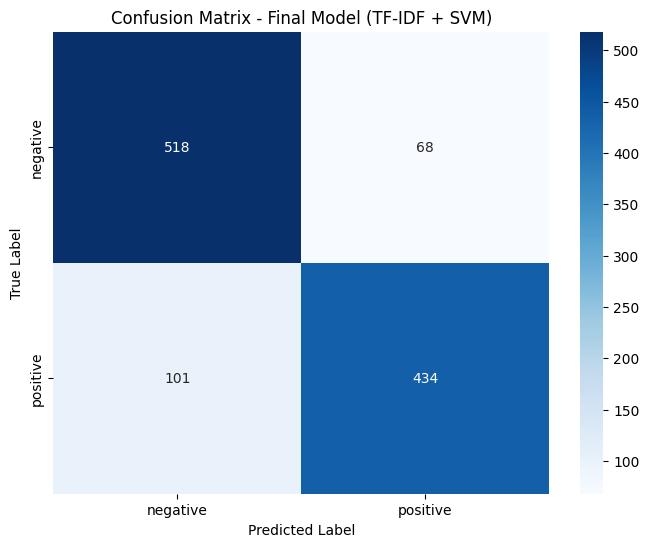

In [ ]:
labels = ['negative', 'positive']

cm = confusion_matrix(y_test, y_test_pred, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=labels,yticklabels=labels)

plt.title("Confusion Matrix - Final Model (TF-IDF + SVM)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("confusion_matrix_final.png", dpi=300, bbox_inches="tight")
plt.show()

## **LLM Approach**

In [ ]:
df.head()

,ID,TWEET,LABEL
0,1,الاوليمبياد الجايه هكون لسه ف الكليه ..,none
1,2,عجز الموازنه وصل ل93.7 % من الناتج المحلي يعني...,anger
2,3,كتنا نيله ف حظنا الهباب xD,sadness
3,4,جميعنا نريد تحقيق اهدافنا لكن تونس تالقت في حر...,joy
4,5,الاوليمبياد نظامها مختلف .. ومواعيد المونديال ...,none


In [ ]:
mapping = {
    "joy": "Positive",
    "love": "Positive",
    "sympathy": "Positive",

    "anger": "Negative",
    "sadness": "Negative",
    "fear": "Negative"
}

df_mapping= df.copy()

df_mapping[" LABEL"] = df_mapping[" LABEL"].map(mapping)


df_mapping= df_mapping.dropna(subset=[" LABEL"])


### **one-shot approach**

In [ ]:
!pip install git+https://github.com/huggingface/accelerate.git
!pip install git+https://github.com/huggingface/transformers.git
!pip install -U bitsandbytes>=0.46.1

  Cloning https://github.com/huggingface/accelerate.git to /tmp/pip-req-build-1nlalima
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/accelerate.git /tmp/pip-req-build-1nlalima
  Resolved https://github.com/huggingface/accelerate.git to commit 29e03d185d6c4608472b3b866964c8942c2fa4a3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for accelerate: filename=accelerate-1.14.0.dev0-py3-none-any.whl size=386923 sha256=c7521efe05fa1d91b34f848f59993f36d364df7ecb79605267a729f2b4d88cae
  Stored in directory: /tmp/pip-ephem-wheel-cache-v0cls_5w/wheels/5a/20/fb/1221fe933b56fe7ac69fd00159d9a1950bc8ced38198abc18f
Successfully built accelerate
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.13.0
    Uninstalling accelerate-1.13.0:
      Successfully uninstalled accelerate-1.13.0
  Cloning https://github.com/huggingface/transfor

In [ ]:
from google.colab import userdata
from huggingface_hub import login

hf_token = userdata.get("HF_TOKEN")
login(token=hf_token)

import torch
import re
import pandas as pd

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from sklearn.metrics import (accuracy_score,f1_score, precision_score,recall_score,classification_report,confusion_matrix)

In [ ]:
torch.cuda.empty_cache()

model_name = "ALLaM-AI/ALLaM-7B-Instruct-preview"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    llm_int8_enable_fp32_cpu_offload=True
)

device_map = {"": 0}

print("Loading Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Loading Model...")
allam_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map=device_map
)

print("Model Loaded Successfully")

Loading Tokenizer...


config.json:   0%|          | 0.00/686 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Loading Model...


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Model Loaded Successfully


In [ ]:
def clean_prediction(generated_text):
    text = generated_text.strip().lower()

    if "positive" in text:
        return "Positive"
    elif "negative" in text:
        return "Negative"
    else:
        return "Unknown"

In [ ]:
def classify_tweet_oneshot(tweet_text):

    query = f"""
You are an expert in Arabic sentiment analysis.

Task: Classify the following Arabic tweet into exactly one of these two categories: Positive or Negative.

Example:
Tweet: "أنا سعيدة جدًا اليوم"
Classification: Positive

Strict Rules:
- You must answer with exactly ONE English word only: Positive or Negative.
- Do NOT use the word Neutral.
- Do NOT provide explanations, notes, or additional text.

Tweet: "{tweet_text}"

Classification:
"""

    messages = [{"role": "user", "content": query}]

    inputs = tokenizer.apply_chat_template(messages,tokenize=False)

    inputs = tokenizer(inputs,return_tensors="pt",return_token_type_ids=False)

    inputs = {k: v.to("cuda") for k, v in inputs.items()}

    response = allam_model.generate(**inputs,max_new_tokens=10,do_sample=False,pad_token_id=tokenizer.eos_token_id)

    generated_text = tokenizer.decode(response[0][inputs["input_ids"].shape[-1]:],skip_special_tokens=True)

    return clean_prediction(generated_text)

In [ ]:
df_sample = df_mapping.head(500).copy()

df_sample["OneShot_Prediction"] = df_sample[" TWEET"].apply(classify_tweet_oneshot)

df_sample.head()

,ID,TWEET,LABEL,OneShot_Prediction
1,2,عجز الموازنه وصل ل93.7 % من الناتج المحلي يعني...,Negative,Negative
2,3,كتنا نيله ف حظنا الهباب xD,Negative,Negative
3,4,جميعنا نريد تحقيق اهدافنا لكن تونس تالقت في حر...,Positive,Positive
6,7,الحب يسلبها كيدها يرجعها الي براءتها الاولي وي...,Positive,Negative
7,8,she3er: شوفي بـ عيني امنيات الغلابه واحلام ثلث...,Positive,Positive


In [ ]:
print("One-shot Accuracy:", accuracy_score(df_sample[" LABEL"],df_sample["OneShot_Prediction"]))

print("One-shot F1-score:", f1_score(df_sample[" LABEL"],df_sample["OneShot_Prediction"],average="weighted"))

print("One-shot Precision:", precision_score(df_sample[" LABEL"],df_sample["OneShot_Prediction"],average="weighted"))

print("One-shot Recall:", recall_score(df_sample[" LABEL"],df_sample["OneShot_Prediction"],average="weighted"))

print("\nClassification Report:")
print(classification_report(df_sample[" LABEL"],df_sample["OneShot_Prediction"]))

One-shot Accuracy: 0.856
One-shot F1-score: 0.8566973566973567
One-shot Precision: 0.8597677198423467
One-shot Recall: 0.856

Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.89      0.86       250
    Positive       0.89      0.82      0.85       250
     Unknown       0.00      0.00      0.00         0

    accuracy                           0.86       500
   macro avg       0.57      0.57      0.57       500
weighted avg       0.86      0.86      0.86       500



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

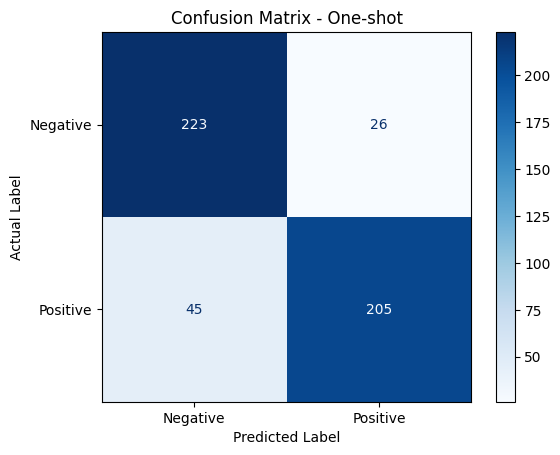

In [ ]:
labels = ["Negative", "Positive"]

cm = confusion_matrix(df_sample[" LABEL"],df_sample["OneShot_Prediction"],labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - One-shot")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.savefig("confusion_matrix_one_shot.png", dpi=300, bbox_inches="tight")

plt.show()

### **Zero-shot approach**

In [ ]:
!pip install git+https://github.com/huggingface/accelerate.git
!pip install git+https://github.com/huggingface/transformers.git
!pip install -U bitsandbytes>=0.46.1

  Cloning https://github.com/huggingface/accelerate.git to /tmp/pip-req-build-mtabjodd
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/accelerate.git /tmp/pip-req-build-mtabjodd
  Resolved https://github.com/huggingface/accelerate.git to commit 29e03d185d6c4608472b3b866964c8942c2fa4a3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-bji9o2y0
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-bji9o2y0
  Resolved https://github.com/huggingface/transformers.git to commit bb911642fdb31bd59a800de394ed172671bb2fe4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from huggingface_hub import login
from google.colab import userdata


hf_token = userdata.get('Allam2')

login(token=hf_token)

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import re
import os


torch.cuda.empty_cache()

model_name = "ALLaM-AI/ALLaM-7B-Instruct-preview"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    llm_int8_enable_fp32_cpu_offload=True
)

device_map = {"": 0}

print("Loading Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

#Loading Model into GPU Memory
allam_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map=device_map
)

Loading Tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [ ]:
def classify_tweet_zeroshot(tweet_text):
    # Prompt
    query = f"""You are an expert in Arabic sentiment analysis.
Task: Classify the following Arabic tweet into exactly one of these two categories: (Positive, Negative).

Strict Rules:
- You must answer with exactly ONE English word from the given options.
- Do NOT use the word 'Neutral'.
- Do NOT provide any explanations, notes, or additional text.

Tweet: "{tweet_text}"
Classification:"""

    messages = [{"role": "user", "content": query}]
    inputs = tokenizer.apply_chat_template(messages, tokenize=False)
    inputs = tokenizer(inputs, return_tensors='pt', return_token_type_ids=False)

    inputs = {k: v.to('cuda') for k, v in inputs.items()}
    max_input_length = tokenizer.model_max_length

    if len(inputs['input_ids'][0]) > max_input_length:
        inputs['input_ids'] = inputs['input_ids'][:, :max_input_length]
        inputs['attention_mask'] = inputs['attention_mask'][:, :max_input_length]

    response = allam_model.generate(
        **inputs,
        max_new_tokens=10,
        do_sample=True,
        top_k=50,
        top_p=0.95,
        temperature=0.1
    )

    generated_text = tokenizer.batch_decode(response, skip_special_tokens=True)[0]
    pattern = r"\[INST\].*?\[/INST\]"
    generated_text = re.sub(pattern, "", generated_text, flags=re.DOTALL)

    result = os.linesep.join([s for s in generated_text.splitlines() if s]).strip()

    return result

In [ ]:
test_tweet = "الخدمة ممتازة جداً وتجربة رائعة"
test_tweet2="الجو خايس"
print(f"Test Result: {classify_tweet_zeroshot(test_tweet)}")
print(f"Test Result: {classify_tweet_zeroshot(test_tweet2)}")

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Test Result: Positive
Test Result: Negative


In [ ]:
df_sample =df_mapping.head(500).copy()
df_sample['Predicted_Sentiment'] = df_sample[' TWEET'].apply(classify_tweet_zeroshot)

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[tra

In [ ]:
# evaluation
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
print("Zero-shot Accuracy:", accuracy_score(df_sample[' LABEL'], df_sample['Predicted_Sentiment']))

print("\nClassification Report:")
print(classification_report(df_sample[' LABEL'], df_sample['Predicted_Sentiment']))

print("\nConfusion Matrix:")
print(confusion_matrix(df_sample[' LABEL'], df_sample['Predicted_Sentiment']))

Zero-shot Accuracy: 0.854

Classification Report:
              precision    recall  f1-score   support

    Confused       0.00      0.00      0.00         0
    Negative       0.84      0.87      0.86       250
     Neutral       0.00      0.00      0.00         0
    Positive       0.88      0.84      0.86       250

    accuracy                           0.85       500
   macro avg       0.43      0.43      0.43       500
weighted avg       0.86      0.85      0.86       500


Confusion Matrix:
[[  0   0   0   0]
 [  0 218   3  29]
 [  0   0   0   0]
 [  1  40   0 209]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### **Few Shots approach**

In [ ]:
!pip install git+https://github.com/huggingface/accelerate.git
!pip install git+https://github.com/huggingface/transformers.git
!pip install -U bitsandbytes>=0.46.1

  Cloning https://github.com/huggingface/accelerate.git to /tmp/pip-req-build-1xq5xu8x
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/accelerate.git /tmp/pip-req-build-1xq5xu8x
  Resolved https://github.com/huggingface/accelerate.git to commit 29e03d185d6c4608472b3b866964c8942c2fa4a3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for accelerate: filename=accelerate-1.14.0.dev0-py3-none-any.whl size=386923 sha256=48a4dd97b229349d19f1b41202d59641279eb42c5550ffa514de6c07c45c394b
  Stored in directory: /tmp/pip-ephem-wheel-cache-smny0i7g/wheels/5a/20/fb/1221fe933b56fe7ac69fd00159d9a1950bc8ced38198abc18f
Successfully built accelerate
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.13.0
    Uninstalling accelerate-1.13.0:
      Successfully uninstalled accelerate-1.13.0
  Cloning https://github.com/huggingface/transfor

In [ ]:
from huggingface_hub import login
from google.colab import userdata
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import re
import os

In [ ]:
hf_token = userdata.get("access_token")
login(token=hf_token)

In [ ]:
torch.cuda.empty_cache()

In [ ]:
model = "ALLaM-AI/ALLaM-7B-Instruct-preview"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    llm_int8_enable_fp32_cpu_offload=True
)
device_map = {"": 0}

tokenizer = AutoTokenizer.from_pretrained(model)

allam_model = AutoModelForCausalLM.from_pretrained(
    model,
    quantization_config=bnb_config,
    device_map=device_map
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/686 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

In [ ]:
def fewshot(tweet):

  messages = [
        {"role": "user", "content": f"""You are an expert in Arabic sentiment analysis.
        Task: Classify the following Arabic tweet into exactly one of these two categories: (Positive, Negative).

        Strict Rules:
        - You must answer with exactly ONE English word from the given options.
        - Do NOT use the word 'Neutral'.
        - Do NOT provide any explanations, notes, or additional text.

        Tweet: (عجز الموازنه وصل ل93.7 % من الناتج المحلي يعني لسه اقل من 7 % و نفلس و بهايم لسه يتابعوا الاوليمبياد)
        Sentiment: negative

        Tweet: (اجمل ماقيل بالحب عن الام امي لا تؤم القلوب الا اليك ولا تلين الصخور الا لحنانك انتِ و الجنه تحت قدميك)
        Sentiment: positive

        Tweet: (عندما نشتاق لمن فقدناهم ، تغيب لذة كل شئ بالحياة ابدا ليس سهلا ما يسمى بالحنين)
        Sentiment: negative

        Tweet: (صباح_الخير اللهم.. طهر صباحنا وصباح كل مسلم من الهم والحزن وافتح لنا أبواب السعادة والأمل..)
        Sentiment: positive

        Text: ({tweet})
        Sentiment: """}
    ]

  inputs = tokenizer.apply_chat_template(messages, tokenize = False)

  inputs = tokenizer(inputs, return_tensors="pt", return_token_type_ids=False)

  inputs = {k:v.to('cuda') for k,v in inputs.items()}

  response = allam_model.generate(**inputs, max_new_tokens=5, do_sample=False, pad_token_id=tokenizer.eos_token_id)

  generated_text = tokenizer.decode( response[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)

  return generated_text

In [ ]:
df_sample = df_mapping.head(500).copy()

df_sample["FewShot_Prediction"] = df_sample[" TWEET"].apply(fewshot)
df_sample.head()

,ID,TWEET,LABEL,FewShot_Prediction
1,2,عجز الموازنه وصل ل93.7 % من الناتج المحلي يعني لسه اقل من 7 % و نفلس و بهايم لسه يتابعوا الاوليمبياد,Negative,negative
2,3,كتنا نيله ف حظنا الهباب xD,Negative,negative
3,4,جميعنا نريد تحقيق اهدافنا لكن تونس تالقت في حراسه المرمي...,Positive,positive
6,7,الحب يسلبها كيدها يرجعها الي براءتها الاولي ويدفعها الي الذهاب بعيداً حيث لا تعرف وحيث تخاف فهي لا تقاومك احياناً بل تقاوم نفسها ان تحب,Positive,positive
7,8,she3er: شوفي بـ عيني امنيات الغلابه واحلام ثلثين الشعوب .! . سنابي she3er1 .,Positive,positive


In [ ]:
df_sample['FewShot_Prediction'] = df_sample['FewShot_Prediction'].str.lower().str.strip()
df_sample[" LABEL"] = df_sample[" LABEL"].str.lower().str.strip()

In [ ]:
print(classification_report(df_sample[" LABEL"], df_sample["FewShot_Prediction"]))

              precision    recall  f1-score   support

    negative       0.85      0.84      0.85       250
     neutral       0.00      0.00      0.00         0
    positive       0.85      0.85      0.85       250

    accuracy                           0.85       500
   macro avg       0.57      0.57      0.57       500
weighted avg       0.85      0.85      0.85       500



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


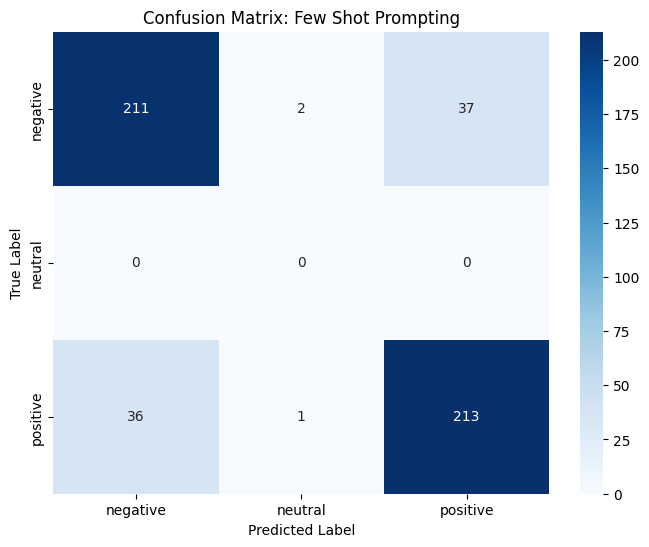

In [ ]:
labels = ['negative', 'neutral' ,'positive']

cm = confusion_matrix(df_sample[" LABEL"], df_sample["FewShot_Prediction"], labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=labels,yticklabels=labels)

plt.title("Confusion Matrix: Few Shot Prompting")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()